In [1]:
# Implementation (Hands-on)Let's imagine we have a tiny dataset of 5 houses.
# $X$ (Feature): Size of the house (in thousands of sq ft).
# $y$ (Target): Price of the house (in hundreds of thousands of dollars).

In [2]:
import numpy as np

In [3]:
#our tiny dataset
X = np.array([1,2,3,4,5]) #House Sizes
y = np.array([1.2, 1.9, 3.2, 3.8, 5.1]) #prices
n = len(X)

In [4]:
# 2. Initialize our parameters (Start at the top of the mountain)
w = 0.0 #weight (slope)
b = 0.0 #bias (intercept)
# 3. Hyperparameters
learning_rate = 0.01 # How big of a step to take down a mountain
epochs = 1000 # How many steps taken

In [5]:
#gradient descent loop
for i in range(epochs):
    # Step A: Make predictions using current w and b (Hypothesis: y = wx + b)
    y_pred = w*X + b
    # Step B: Calculate the Gradients (The slope of the MSE error bowl)
    # The mathematical derivative of MSE with respect to w and b
    dw = (2/n) * np.sum(X * (y_pred - y))
    db = (2/n) * np.sum((y_pred - y))
    # Step C: Update the parameters (Take a step downhill!)
    w = w - learning_rate * dw
    b = b - learning_rate * db
print(f"Scratch Model -> Weight: {w:.4f}, Bias: {b:.4f}")

Scratch Model -> Weight: 0.9688, Bias: 0.1344


In [6]:
# Regularization Strength (Lambda)
lambda_param = 0.5 

# Reset weights
w_ridge = 0.0
b_ridge = 0.0

for i in range(epochs):
    y_pred = w_ridge * X + b_ridge
    # NEW: Notice the "+ 2 * lambda_param * w_ridge" at the end!
    # This is the mathematical "fine" for having a large weight.
    dw = (2/n) * np.sum(X*(y - y_pred)) + (2*lambda_param*w_ridge)
    db = (2/n) * np.sum(y - y_pred)

    w_ridge = w_ridge - learning_rate*dw
    b_ridge = b_ridge - learning_rate*db
print(f"Scratch Ridge -> Weight: {w_ridge:.4f}, Bias: {b_ridge:.4f}")

Scratch Ridge -> Weight: -90931489323342544933367313059574071360475346545523314036939120792355789150561013940092928.0000, Bias: -26311064734872114179546698863704124031109546407626714827578212375310547191304218312966144.0000


In [7]:
from sklearn.linear_model import LinearRegression, Ridge

# Scikit-learn expects 2D arrays for X (e.g., rows of samples, columns of features)
X_sklearn = X.reshape(-1, 1) 

# 1. Standard Linear Regression
model = LinearRegression()
model.fit(X_sklearn, y) # This runs the math to find the bottom of the bowl
print(f"Sklearn Model -> Weight: {model.coef_[0]:.4f}, Bias: {model.intercept_:.4f}")

# 2. Ridge (L2) Regression
ridge_model = Ridge(alpha=0.5) # alpha is Scikit-learn's name for lambda
ridge_model.fit(X_sklearn, y)
print(f"Sklearn Ridge -> Weight: {ridge_model.coef_[0]:.4f}, Bias: {ridge_model.intercept_:.4f}")

Sklearn Model -> Weight: 0.9700, Bias: 0.1300
Sklearn Ridge -> Weight: 0.9238, Bias: 0.2686


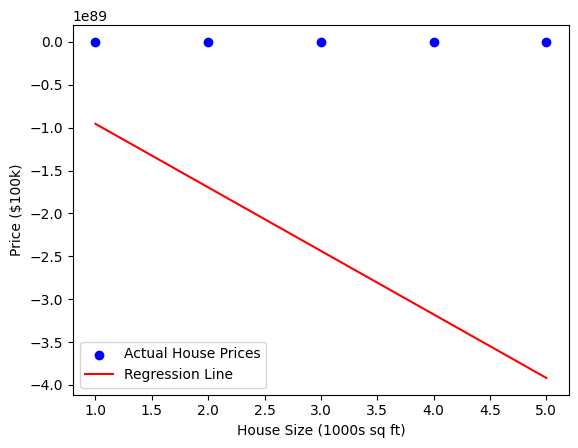

In [9]:
import matplotlib.pyplot as plt

# Plot the actual data points
plt.scatter(X, y, color='blue', label='Actual House Prices')

# Plot our model's predictions (the line)
plt.plot(X, y_pred, color='red', label='Regression Line')

plt.xlabel('House Size (1000s sq ft)')
plt.ylabel('Price ($100k)')
plt.legend()
plt.show()